In [183]:
pip install torchdiffeq

Note: you may need to restart the kernel to use updated packages.


In [184]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
from torchdiffeq import odeint

In [185]:
import sys 
sys.path.insert(0, '/Users/elliephan/hippocampus_latent_dynamics/PO-OU' )
import hippocampalseq.preprocessing as hsep 

data_path = '/Users/elliephan/hippocampus-latent-dynamics/data'
rat_name = "Janni"
session = 1
track_type = "Open"



In [186]:
import hippocampalseq.preprocessing as hsep

raw_data, place_field_data, theta_data, ripple_data = hsep.preprocess_data(
    rat_name, session, data_path,
    track_type=track_type,
    place_field_posterior=False,
    environment_size=(0,0,200,200),
    velocity_cutoff=5.0,
    bin_size_cm=2,
    theta_time_window_ms=250,
    theta_time_window_advance_ms=250,
    ripple_time_window_ms=5.0,
    ripple_time_window_advance_ms=5.0
)

print("Data loaded!")
print("Number of neurons:", place_field_data.place_fields.shape[0])
print("Number of sequences:", len(theta_data.theta_spikes))
print("Spike shape:", theta_data.theta_spikes[0].shape)

Data loaded!
Number of neurons: 204
Number of sequences: 202
Spike shape: (9, 204)


In [187]:
class ODEFunc(nn.Module): #how does z change at each moment in time 
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), 
            nn.Tanh(),
            nn.Linear(64, latent_dim)
        )
    def forward(self, t, z):
        return self.net(z)

In [188]:
class SpikeEncoder(nn.Module):
    def __init__(self, n_neurons, latent_dim):
        super().__init__()
        self.rnn = nn.GRU(n_neurons, 64, batch_first=True)
        self.fc = nn.Linear(64, latent_dim * 2)
    
    def forward(self, spikes):
        _, h = self.rnn(spikes.unsqueeze(0))
        out = self.fc(h.squeeze(0))
        mean, logvar = out.chunk(2, dim=-1)
        return mean, logvar

In [189]:
class PoissonDecoder(nn.Module):
    def __init__(self, latent_dim, n_neurons):
        super().__init__()
        self.C = nn.Linear(latent_dim, n_neurons) #goes from firing rates to z
    def forward(self, z):
        return torch.exp(self.C(z)) #ok this self.C thingy do C x z + d

In [190]:
class PoissonODE(nn.Module):
    def __init__(self, n_neurons, latent_dim):
        super().__init__()
        self.encoder = SpikeEncoder(n_neurons, latent_dim)
        self.ode_func = ODEFunc(latent_dim)
        self.decoder = PoissonDecoder(latent_dim, n_neurons)
        
    def forward(self, spikes, t): # t is the time points you want the ODE to solve for 
        mean, logvar = self.encoder(spikes)
        z0 = mean   #for now, just use the mean as the initial condition
        z = odeint(self.ode_func, z0, t) #solve the ODE to get z(t) at all time points in t
        rates = self.decoder(z) #decode z(t) to get firing rates at each time point
        return rates, z, mean, logvar
    

In [191]:
n_neurons = 204
latent_dim = 2  # 2D because we're decoding 2D position
t = torch.linspace(0, 1, 9)  # 9 timesteps

model = PoissonODE(n_neurons, latent_dim)
print(model)

PoissonODE(
  (encoder): SpikeEncoder(
    (rnn): GRU(204, 64, batch_first=True)
    (fc): Linear(in_features=64, out_features=4, bias=True)
  )
  (ode_func): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (decoder): PoissonDecoder(
    (C): Linear(in_features=2, out_features=204, bias=True)
  )
)


In [192]:
spikes = torch.tensor(theta_data.theta_spikes[0], dtype=torch.float32)
print("spikes shape:", spikes.shape)

spikes shape: torch.Size([9, 204])


In [193]:
spikes = torch.tensor(theta_data.theta_spikes[0], dtype=torch.float32)
rates, z, mean, logvar = model(spikes, t) #pass only 2 argu, but catch 3 returned values
print("rates shape:", rates.shape) # we will have 9 timesetps, 2d latent position
print("z shape:", z.shape) #9 timesteps, 204 neurons firing rates 

rates shape: torch.Size([9, 1, 204])
z shape: torch.Size([9, 1, 2])


In [194]:

def log_likelihood(spikes, rates, dt=0.25):
    #rates: predicted firing rate(9, 204)
    #spikes: actual spike count (9, 204)
    ll = - rates * dt + spikes * torch.log(rates + 1e-8)
    #discrete version + log rate at each spike time
    return -ll.sum()

In [195]:
print("rates shape:", rates.shape)
print("spikes shape:", spikes_tensor.shape)
print("t shape:", t.shape)
print("t:", t)

rates shape: torch.Size([9, 1, 204])
spikes shape: torch.Size([9, 204])
t shape: torch.Size([9])
t: tensor([0.0000, 0.1250, 0.2500, 0.3750, 0.5000, 0.6250, 0.7500, 0.8750, 1.0000])


In [196]:
spikes_tensor = torch.tensor(theta_data.theta_spikes[0], dtype = torch.float32)
loss = log_likelihood(spikes_tensor, rates)
print("loss", loss.item()) #big number because didnt train the model yet

loss 5061.0029296875


# Training models
*show it some spikes - heres when the neurons fired*


*Ask it to predict - what firing rates do you think it caused 
this*


*Calculate how wrong it was - the loss*

*Nudge the weights to be less wrong next time - thats the optimizer*

**Using gradient descent?**

In [197]:
"""
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(100):
    total_loss = 0
    for spikes in theta_data.theta_spikes:
        spikes_tensor = torch.tensor(spikes, dtype=torch.float32)
        t = torch.linspace(0, 1, spikes_tensor.shape[0])
        rates, z = model(spikes_tensor, t)
        loss = log_likelihood(rates, spikes_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0 :
        print(f"Epoch {epoch}, Loss: {total_loss/len(theta_data.theta_spikes):.2f}")
"""

'\noptimizer = torch.optim.Adam(model.parameters(), lr=1e-3)\n\nfor epoch in range(100):\n    total_loss = 0\n    for spikes in theta_data.theta_spikes:\n        spikes_tensor = torch.tensor(spikes, dtype=torch.float32)\n        t = torch.linspace(0, 1, spikes_tensor.shape[0])\n        rates, z = model(spikes_tensor, t)\n        loss = log_likelihood(rates, spikes_tensor)\n        \n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n        total_loss += loss.item()\n    if epoch % 10 == 0 :\n        print(f"Epoch {epoch}, Loss: {total_loss/len(theta_data.theta_spikes):.2f}")\n'

take spikes data --> send it thru the model --> get latent state z --> plot the 2d latent trajectory 

In [199]:
"""
#takes spike data and turns into pytorch tensor
spikes_tensor = torch.tensor(spikes, dtype=torch.float32)
#create a time vector from 0 to 1
t = torch.linspace(0, 1, spikes_tensor.shape[0])
rates, z, mean, logvar = model(spikes_tensor, t) #sent the time and spike data into model

z_np = z.detach().numpy()
plt.figure(figsize=(6,6))
plt.plot(z_np[:, 0], z_np[:, 1])
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('Latent trajectory')
plt.show()
"""

"\n#takes spike data and turns into pytorch tensor\nspikes_tensor = torch.tensor(spikes, dtype=torch.float32)\n#create a time vector from 0 to 1\nt = torch.linspace(0, 1, spikes_tensor.shape[0])\nrates, z, mean, logvar = model(spikes_tensor, t) #sent the time and spike data into model\n\nz_np = z.detach().numpy()\nplt.figure(figsize=(6,6))\nplt.plot(z_np[:, 0], z_np[:, 1])\nplt.xlabel('z1')\nplt.ylabel('z2')\nplt.title('Latent trajectory')\nplt.show()\n"

**model is cheating**

right now just have the poisson likelihood to tell the model to predicts the spikes well, but didnt define  so model makes z go to huge negative numbers, because thats make the firing rates close to zero. which technically explain the sparse spikes but isnt learning anything meaning about the Janni movement 

# KL Divergence 
The penalty to tell z should stay close to normal distribution, toward 0 and make the model actually learn the structure in the latent space 

In [200]:
def kl_divergence(mean, logvar):
    kl = -0.5 * torch.sum(1 + logvar - mean**2 - torch.exp(logvar))
    return kl


In [201]:
def kl_loss(rates, spikes, mean, logvar, beta=0.1):
    pl = log_likelihood(spikes, rates)
    kl = kl_divergence(mean, logvar)
    return pl  + beta * kl

notes: spikes is raw data (2d matrix of shape [neurons, times]), rates comes out of odeint, which add time dimension (3d of shape [time_steps, batchsize neurons]) -- need to fix it before feed to kl 


In [207]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
beta = 1.0

for epoch in range(2000):
    total_loss = 0
    for spikes in theta_data.theta_spikes:
        spikes_tensor = torch.tensor(spikes, dtype=torch.float32)
        t = torch.linspace(0, 1, spikes_tensor.shape[0])
        rates, z, mean, logvar = model(spikes_tensor, t)
        loss = kl_loss(rates, spikes_tensor, mean, logvar, beta=beta)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(theta_data.theta_spikes):.2f}")
torch.save(model.state_dict(), 'poisson_ode_model.pth')
print("Model trained and saved!")

Epoch 0, Loss: 347.78


KeyboardInterrupt: 

In [210]:
z_np = z.squeeze(1).detach().numpy()

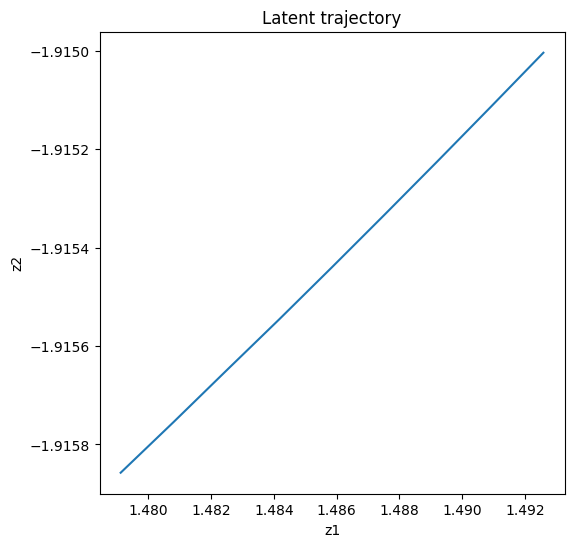

In [212]:
spikes_tensor = torch.tensor(theta_data.theta_spikes[0], dtype=torch.float32)
t = torch.linspace(0, 1, spikes_tensor.shape[0])
rates, z, mean, logvar = model(spikes_tensor, t)

z_np = z.squeeze(1).detach().numpy()
plt.figure(figsize=(6,6))
plt.plot(z_np[:, 0], z_np[:, 1])
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('Latent trajectory')
plt.show()

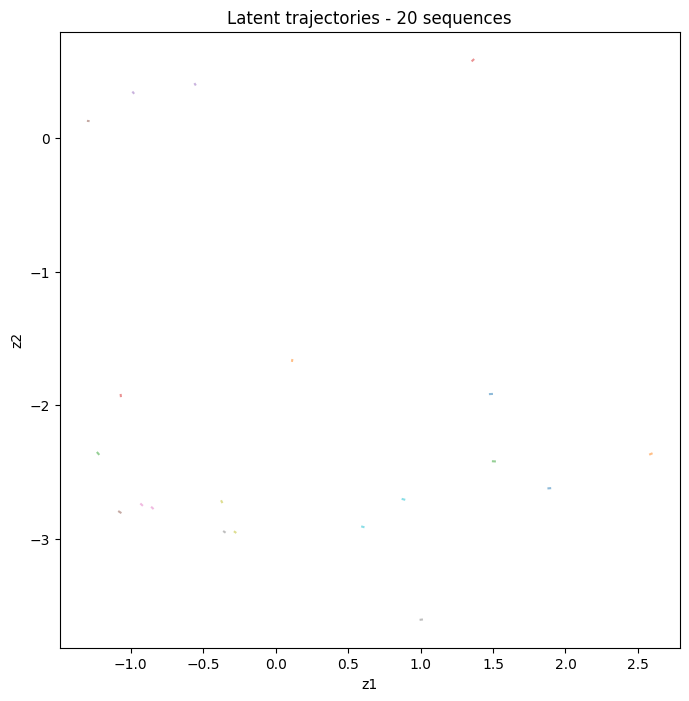

In [213]:
plt.figure(figsize=(8,8))
for i in range(20):
    spikes_tensor = torch.tensor(theta_data.theta_spikes[i], dtype=torch.float32)
    t = torch.linspace(0, 1, spikes_tensor.shape[0])
    rates, z, mean, logvar = model(spikes_tensor, t)
    z_np = z.squeeze(1).detach().numpy()
    plt.plot(z_np[:, 0], z_np[:, 1], alpha=0.5)

plt.xlabel('z1')
plt.ylabel('z2')
plt.title('Latent trajectories - 20 sequences')
plt.show()